**Section 1: Dataset**

For this project, I chose the **Estimation of Obesity Levels Based on Eating Habits and Physical Condition** dataset. I selected this dataset because I am passionate about health, fitness, and understanding how lifestyle patterns influence obesity. Preventing obesity is a global challenge, and I wanted to explore the behavioral and biological causes using real data.

This dataset contains **2111 records**, **17 attributes**, and includes demographic information, eating habits, and physical activity patterns. I found it through the UCI Machine Learning Repository.

I want to discover which variables most strongly contribute to obesity levels and whether certain behaviors predict a person's obesity category.

Below, I loaded the dataset.

In [2]:
import pandas as pd
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
df


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


Dataset Size

To understand the scale of the dataset, I checked the number of rows and columns.

In [3]:
row_size = len(df)
row_size

2111

In [4]:
column_size = len(df.columns)
column_size

17

Column Names

Listing the column names provides an overview of all features available for analysis, including numerical and categorical variables.


In [5]:
column_names = df.columns
column_names

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

**Section 2**

Measures of Center: Mean

The mean helps summarize the average value of numerical variables such as Age, Weight, and Height. It gives a general sense of where the data tends to cluster.

In [9]:
df_numeric_factors = df[["Age", "Weight", "Height"]].mean()
df_numeric_factors

Age       24.312600
Weight    86.586058
Height     1.701677
dtype: float64

Measures of Center: Median

The median helps understand the center of the distribution while being resistant to outliers. This is helpful when analyzing weight- or height-related data that may have extreme values.


In [10]:
df[["Age", "Weight", "Height"]].median()


Age       22.777890
Weight    83.000000
Height     1.700499
dtype: float64

Measures of Center: Mode

The mode is helpful for categorical variables like Gender, Smoking, Family History, and Obesity Levels. It identifies the most common category in each column.


In [11]:
df.mode(numeric_only=False).iloc[0]

Gender                                             Male
Age                                                18.0
Height                                              1.7
Weight                                             80.0
family_history_with_overweight                      yes
FAVC                                                yes
FCVC                                                3.0
NCP                                                 3.0
CAEC                                          Sometimes
SMOKE                                                no
CH2O                                                2.0
SCC                                                  no
FAF                                                 0.0
TUE                                                 0.0
CALC                                          Sometimes
MTRANS                            Public_Transportation
NObeyesdad                               Obesity_Type_I
Name: 0, dtype: object

Measures of Spread: Standard Deviation

The standard deviation shows how spread out the numerical data is. This helps determine whether variables vary heavily across individuals (e.g., Weight and Age).


In [14]:
df[["Age", "Weight", "Height"]].std()


Age        6.345968
Weight    26.191172
Height     0.093305
dtype: float64

Measures of Spread: Min/Max

The minimum and maximum values give the full range of each numerical variable, helping identify possible outliers or unrealistic values.


In [15]:
df[["Age", "Weight", "Height"]].agg(["min", "max"])

,Age,Weight,Height
min,14.0,39.0,1.45
max,61.0,173.0,1.98


Quartiles (25%, 50%, 75%)

Quartiles help summarize the distribution of the data. They indicate how values are spread and whether the data is symmetric or skewed.


In [16]:
df[["Age", "Weight", "Height"]].quantile([0.25, 0.5, 0.75])


,Age,Weight,Height
0.25,19.947192,65.473343,1.630000
0.50,22.777890,83.000000,1.700499
0.75,26.000000,107.430682,1.768464


GroupBy Mean Weight by Obesity Class

In [17]:
df.groupby("NObeyesdad")["Weight"].mean().sort_values()

NObeyesdad
Insufficient_Weight     49.906330
Normal_Weight           62.155052
Overweight_Level_I      74.266828
Overweight_Level_II     82.085271
Obesity_Type_I          92.870198
Obesity_Type_II        115.305311
Obesity_Type_III       120.941114
Name: Weight, dtype: float64

Correlation Matrix (numeric variables)

In [18]:
df.corr(numeric_only=True)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
Age,1.000000,-0.025958,0.202560,0.016291,-0.043944,-0.045304,-0.144938,-0.296931
Height,-0.025958,1.000000,0.463136,-0.038121,0.243672,0.213376,0.294709,0.051912
Weight,0.202560,0.463136,1.000000,0.216125,0.107469,0.200575,-0.051436,-0.071561
FCVC,0.016291,-0.038121,0.216125,1.000000,0.042216,0.068461,0.019939,-0.101135
NCP,-0.043944,0.243672,0.107469,0.042216,1.000000,0.057088,0.129504,0.036326
CH2O,-0.045304,0.213376,0.200575,0.068461,0.057088,1.000000,0.167236,0.011965
FAF,-0.144938,0.294709,-0.051436,0.019939,0.129504,0.167236,1.000000,0.058562
TUE,-0.296931,0.051912,-0.071561,-0.101135,0.036326,0.011965,0.058562,1.000000


Grouped Summary Statistics

In [19]:
df.groupby("NObeyesdad")[["Age", "Weight", "Height", "FCVC", "NCP"]].agg(["mean", "median", "std"])

Age                           Weight              \
                          mean     median       std        mean      median   
NObeyesdad                                                                    
Insufficient_Weight  19.783237  19.244594  2.669511   49.906330   50.000000   
Normal_Weight        21.738676  21.000000  5.096756   62.155052   61.000000   
Obesity_Type_I       25.884941  22.975526  7.755700   92.870198   90.744965   
Obesity_Type_II      28.233785  27.186873  4.868199  115.305311  117.792268   
Obesity_Type_III     23.495554  25.369387  2.764324  120.941114  112.049308   
Overweight_Level_I   23.417674  21.045204  6.125076   74.266828   75.000000   
Overweight_Level_II  26.996981  24.000000  8.061061   82.085271   82.000000   

                                  Height                          FCVC  \
                           std      mean    median       std      mean   
NObeyesdad                                                               
Insufficient_Weight   6.010708  1.691117  1.704180  0.099687  2.480788   
Normal_Weight         9.296031  1.676585  1.660000  0.094526  2.334495   
Obesity_Type_I       11.485987  1.693804  1.681855  0.098414  2.186050   
Obesity_Type_II       8.024320  1.771795  1.767140  0.072723  2.391284   
Obesity_Type_III     15.532225  1.687559  1.668995  0.065263  3.000000   
Overweight_Level_I    8.470944  1.687836  1.691638  0.095999  2.264631   
Overweight_Level_II   8.450932  1.703748  1.703914  0.089441  2.260578   

                                              NCP                    
                       median       std      mean  median       std  
NObeyesdad                                                           
Insufficient_Weight  2.708316  0.584797  2.914403  3.0000  0.901268  
Normal_Weight        2.000000  0.590983  2.738676  3.0000  0.871861  
Obesity_Type_I       2.000000  0.431998  2.431862  3.0000  0.789471  
Obesity_Type_II      2.432355  0.489808  2.744555  3.0000  0.578765  
Obesity_Type_III     3.000000  0.000000  3.000000  3.0000  0.000000  
Overweight_Level_I   2.000000  0.482626  2.504218  3.0000  0.962811  
Overweight_Level_II  2.000000  0.453272  2.495529  2.9785  0.752908

EDA Observations

The dataset shows that the average participant is about 24 years old, weighs around 87 kg, and is 1.7 m tall, with the median values being slightly lower, suggesting a few heavier individuals in the group. Most participants are male and have a family history of being overweight. Eating habits vary, but many eat high-calorie foods, consume vegetables regularly, and have three main meals a day.

**Section 3: Exploratory Data Visualization**

Visualizations help reveal relationships and trends that are not obvious from summary statistics. I will generate plots that clearly communicate meaningful insights about the dataset. All plots include a title, x-label, and y-label as required.

The visualizations focus on:

- Distribution of numerical variables (e.g., Weight, Age)
- Comparison of behaviors across obesity levels
- Categorical variable frequencies

Histogram: Weight Distribution

The histogram below provides an overview of how weight is distributed in the dataset.
It helps us see whether the distribution is symmetric, skewed, or contains multiple peaks.

This is particularly important because weight is a major factor in determining obesity level. The shape of the histogram can indicate whether the population has a high proportion of normal-weight individuals or whether the dataset leans toward overweight and obese categories.

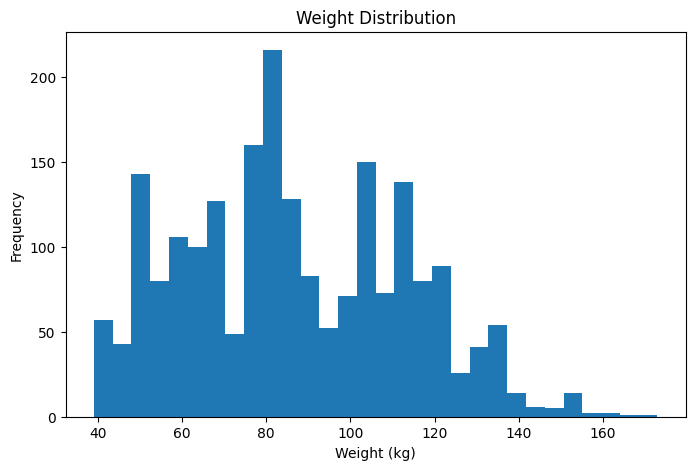

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
plt.hist(df["Weight"], bins=30)
plt.title("Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.show()

Boxplot: Weight by Obesity Class

This boxplot compares weight across all obesity classifications.
Boxplots are useful because they show:

the median weight

the interquartile range (IQR)

outliers

differences in distribution shape across groups

This visualization makes it immediately clear which obesity categories are associated with higher or lower weights.

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
/Library/Frameworks/Python.framework/Versions/3.14/lib/pytho

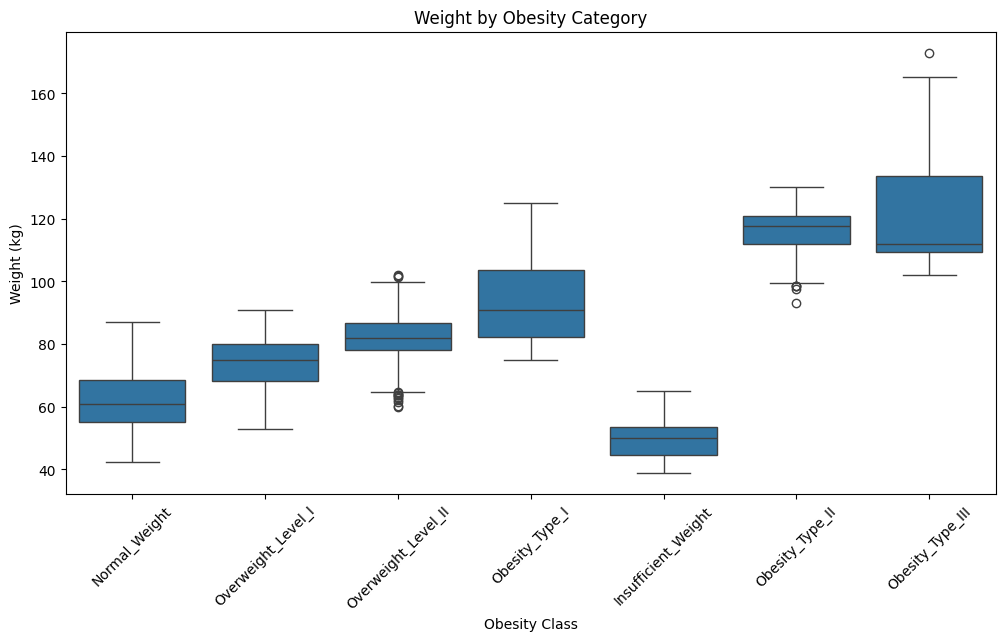

In [21]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="NObeyesdad", y="Weight")
plt.xticks(rotation=45)
plt.title("Weight by Obesity Category")
plt.xlabel("Obesity Class")
plt.ylabel("Weight (kg)")
plt.show()

Visualizations Summary

The weight distribution shows two main peaks around 80 kg and 110 kg, and the boxplot confirms that weight increases steadily across obesity categories from about 60 kg for normal weight to 110 kg for severe obesity, matching our earlier finding that the average participant weighs 87 kg. One interesting question for future analysis would be to examine whether certain combinations of eating habits, like consuming vegetables frequently while also eating high-calorie foods, can reduce obesity risk even in people with a family history of being overweight, potentially using classification methods to identify which lifestyle factors have the strongest protective effects.

**Section 4: Planning for Part II**

Observations from Part I

The dataset shows that the average participant is about 24 years old, weighs around 87 kg, and is 1.7 m tall, with the median values slightly lower, suggesting a few heavier individuals in the group. Most participants are male and have a family history of being overweight. Eating habits vary, but many eat high-calorie foods, consume vegetables regularly, and have three main meals a day. Overall, weight and obesity levels show a wide range, highlighting differences in lifestyle, diet, and possible genetic factors, which could help explain obesity patterns in the population.

Ideas for Part II

For Part II, I plan to explore data-science questions such as:

Which lifestyle or demographic variables are the strongest predictors of obesity level?

Can we build a classification model to estimate obesity levels from diet, activity, and family history?